<a href="https://colab.research.google.com/github/domderr/TradingAlgo/blob/main/TA_Portfolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere file Excel con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 1 - INSTALL, IMPORT, DRIVE
# =============================

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as e:
    print('Google Drive mount skipped or unavailable:', e)

import sys
import subprocess
import warnings
warnings.filterwarnings('ignore')

# Installa solo se necessario
required_packages = {
    'yfinance': 'yfinance',
    'openpyxl': 'openpyxl',
    'xlsxwriter': 'xlsxwriter'
}

for import_name, pip_name in required_packages.items():
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

print('Setup completed.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup completed.


In [28]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere Google Sheet con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 2 - PARAMETRI GENERALI
# =============================

from pathlib import Path

# =============================
# CARTELLE PROGETTO
# =============================

BASE_DIR = Path("/content/drive/MyDrive/AssetAllocation")
BASE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = BASE_DIR / "Output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =============================
# GOOGLE SHEET
# =============================
# Inserisci qui l'ID del Google Sheet
#
# Esempio:
# https://docs.google.com/spreadsheets/d/1AbCdEfGhIjKlMnOpQrStUvWxYz123456/edit#gid=0
#
# SHEET_ID = "1AbCdEfGhIjKlMnOpQrStUvWxYz123456"

SHEET_ID = "Tickers"

GOOGLE_SHEET_CSV_URL = (
    "https://docs.google.com/spreadsheets/d/"
    "11qNgaa-9S2SABWe2emZHUDZ-xLkeef0KA00n5FXxPIQ"
    "/export?format=csv&gid=0"
)

TICKER_COLUMN = "Ticker"

# =============================
# DOWNLOAD DATI
# =============================

START_DATE = "2015-01-01"
END_DATE = None

PRICE_FIELD_PRIORITY = [
    "Adj Close",
    "Close"
]

# =============================
# FREQUENZA
# =============================

WEEKLY_RULE = "W-FRI"

# =============================
# MODELLO
# =============================

K_SELECT_LIST = [3, 5, 7, 10]

RISK_FREE_ANNUAL = 0.01

TRANSACTION_COST = 0.001

# =============================
# GRID SEARCH
# =============================

TREND_LEN_LIST = [52]

SLOPE_MIN_LIST = [
    0.00,

]

R2_MIN_LIST = [

    0.30
]

CORR_MAX_LIST = [
    0.5,

]

CORR_LOOKBACK = 26

# =============================
# CHECK
# =============================

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("GOOGLE_SHEET_CSV_URL:", GOOGLE_SHEET_CSV_URL)

BASE_DIR: /content/drive/MyDrive/AssetAllocation
OUTPUT_DIR: /content/drive/MyDrive/AssetAllocation/Output
GOOGLE_SHEET_CSV_URL: https://docs.google.com/spreadsheets/d/11qNgaa-9S2SABWe2emZHUDZ-xLkeef0KA00n5FXxPIQ/export?format=csv&gid=0


In [29]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere Google Sheet con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 3 - LETTURA GOOGLE SHEET TICKER
# =============================

def read_tickers_from_google_sheet(csv_url, ticker_column='Ticker'):
    # Legge i ticker da Google Sheet; il primo ticker è il benchmark.

    df = pd.read_csv(csv_url)

    if df.empty:
        raise ValueError('Il Google Sheet è vuoto.')

    if ticker_column in df.columns:
        s = df[ticker_column]
    else:
        s = df.iloc[:, 0]

    tickers = (
        s.dropna()
         .astype(str)
         .str.strip()
         .str.upper()
         .replace('', np.nan)
         .dropna()
         .drop_duplicates()
         .tolist()
    )

    if len(tickers) < 2:
        raise ValueError(
            'Servono almeno 2 ticker: primo benchmark + almeno 1 ticker investibile.'
        )

    benchmark = tickers[0]
    universe = tickers[1:]

    return benchmark, universe, tickers, df


benchmark, universe, all_tickers, sheet_raw = (
    read_tickers_from_google_sheet(
        GOOGLE_SHEET_CSV_URL,
        TICKER_COLUMN
    )
)

print('Benchmark:', benchmark)
print('Numero ticker universo:', len(universe))
print('Universo:', universe)

display(sheet_raw.head())

Benchmark: DIA
Numero ticker universo: 30
Universo: ['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SHW', 'TRV', 'UNH', 'V', 'VZ', 'WMT']


,Ticker,Ita,Dj30,Test
0,DIA,FTSEMIB.MI,DIA,DIA
1,AAPL,UCG.MI,AAPL,AAPL
2,AMGN,ISP.MI,AMGN,AMGN
3,AMZN,BAMI.MI,AMZN,AMZN
4,AXP,MB.MI,AXP,AXP


In [30]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere file Excel con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 4 - DOWNLOAD DATI DA YFINANCE
# =============================

def extract_price_table(raw, tickers, field_priority=None):
    # Estrae una tabella prezzi robusta da yfinance, gestendo colonne MultiIndex e campi mancanti.
    if field_priority is None:
        field_priority = ['Adj Close', 'Close']

    if raw is None or raw.empty:
        raise ValueError('Download yfinance vuoto.')

    if isinstance(raw.columns, pd.MultiIndex):
        level0 = list(raw.columns.get_level_values(0).unique())
        level1 = list(raw.columns.get_level_values(1).unique())

        # Caso standard yfinance group_by='column': livello 0 = campi, livello 1 = ticker
        for field in field_priority:
            if field in level0:
                px = raw[field].copy()
                px.columns = [str(c).upper() for c in px.columns]
                return px

        # Caso alternativo: livello 0 = ticker, livello 1 = campi
        for field in field_priority:
            if field in level1:
                px = raw.xs(field, level=1, axis=1).copy()
                px.columns = [str(c).upper() for c in px.columns]
                return px

        raise ValueError(f'Nessun campo prezzo trovato tra: {field_priority}')

    # Caso singolo ticker o colonne semplici
    for field in field_priority:
        if field in raw.columns:
            first_ticker = tickers[0]
            return pd.DataFrame({first_ticker: raw[field]})

    raise ValueError(f'Nessun campo prezzo trovato tra: {field_priority}')


def download_prices_yfinance(tickers, start_date, end_date=None):
    # Scarica i prezzi da yfinance e restituisce una matrice Date x Ticker.
    raw = yf.download(
        tickers=tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False,
        group_by='column',
        threads=True
    )

    px = extract_price_table(raw, tickers, PRICE_FIELD_PRIORITY)
    px = px.sort_index()
    px.index = pd.to_datetime(px.index).tz_localize(None)

    # Mantiene solo i ticker richiesti e nell'ordine corretto, se presenti
    available = [t for t in tickers if t in px.columns]
    missing = [t for t in tickers if t not in px.columns]
    px = px[available]

    # Rimuove colonne completamente vuote
    px = px.dropna(axis=1, how='all')
    missing_after = [t for t in tickers if t not in px.columns]

    if missing_after:
        print('Ticker senza dati o non scaricati:', missing_after)

    if benchmark not in px.columns:
        raise ValueError(f'Benchmark {benchmark} non presente nei dati scaricati.')

    return px

prices_daily = download_prices_yfinance(all_tickers, START_DATE, END_DATE)

print('Date range:', prices_daily.index.min().date(), '->', prices_daily.index.max().date())
print('Colonne scaricate:', list(prices_daily.columns))
display(prices_daily.tail())

Date range: 2015-01-02 -> 2026-05-29
Colonne scaricate: ['DIA', 'AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SHW', 'TRV', 'UNH', 'V', 'VZ', 'WMT']


,DIA,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,GS,HD,HON,IBM,JNJ,JPM,KO,MCD,MMM,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-22,506.119995,308.820007,339.299988,266.320007,311.779999,219.020004,879.890015,180.070007,120.410004,191.429993,103.000000,996.729980,313.070007,227.919998,253.839996,233.000000,306.380005,81.480003,282.269989,152.440002,122.410004,418.570007,44.669998,215.330002,144.440002,309.079987,306.459991,388.470001,328.880005,48.349998,120.269997
2026-05-26,505.250000,308.329987,335.940002,265.290009,310.720001,218.899994,908.549988,179.080002,118.330002,184.710007,103.279999,994.520020,310.540009,231.720001,250.690002,230.179993,306.739990,80.459999,279.260010,154.029999,119.720001,416.029999,44.939999,214.860001,142.960007,311.250000,304.839996,376.859985,326.480011,48.490002,118.570000
2026-05-27,506.880005,310.850006,336.059998,271.850006,312.540009,224.300003,909.929993,177.509995,119.669998,182.399994,104.180000,996.469971,317.850006,231.550003,255.199997,231.289993,299.279999,81.620003,280.920013,155.169998,120.239998,412.670013,45.980000,212.600006,147.490005,309.970001,299.940002,384.010010,327.609985,48.240002,118.540001
2026-05-28,507.049988,312.510010,336.480011,274.000000,315.119995,228.779999,887.669983,176.169998,118.639999,183.029999,103.730003,1008.369995,321.209991,233.000000,264.220001,230.800003,296.730011,80.410004,277.970001,152.850006,119.889999,426.989990,47.369999,214.250000,145.910004,305.140015,294.309998,382.529999,324.950012,48.009998,118.900002
2026-05-29,510.779999,312.059998,336.790009,270.640015,316.470001,231.149994,875.869995,191.100006,120.419998,182.460007,101.830002,1025.560059,317.140015,237.860001,297.799988,225.330002,299.309998,79.010002,279.200012,153.130005,118.720001,450.239990,46.230000,211.139999,143.559998,303.839996,291.890015,380.309998,326.359985,47.810001,115.750000


In [31]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere file Excel con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 5 - PREPARAZIONE DATI SETTIMANALI
# =============================

def prepare_weekly_prices(prices_daily, benchmark, universe, weekly_rule='W-FRI'):
    # Converte i prezzi giornalieri in prezzi settimanali e allinea benchmark/universo.
    prices_weekly = prices_daily.resample(weekly_rule).last().dropna(how='all')
    prices_weekly = prices_weekly.ffill()

    available_universe = [t for t in universe if t in prices_weekly.columns]
    if not available_universe:
        raise ValueError('Nessun ticker investibile disponibile dopo il download.')

    px_bench = prices_weekly[benchmark].dropna()
    px_univ = prices_weekly[available_universe].dropna(how='all').ffill()

    common_index = px_bench.index.intersection(px_univ.index)
    px_bench = px_bench.loc[common_index]
    px_univ = px_univ.loc[common_index]

    returns_univ = px_univ.pct_change().fillna(0.0)
    returns_bench = px_bench.pct_change().fillna(0.0)

    return px_univ, px_bench, returns_univ, returns_bench

px_univ, px_bench, ret_univ, ret_bench = prepare_weekly_prices(prices_daily, benchmark, universe, WEEKLY_RULE)

print('Benchmark:', benchmark)
print('Ticker investibili disponibili:', list(px_univ.columns))
print('Settimane:', len(px_univ))
display(px_univ.tail())

Benchmark: DIA
Ticker investibili disponibili: ['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SHW', 'TRV', 'UNH', 'V', 'VZ', 'WMT']
Settimane: 596


,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,GS,HD,HON,IBM,JNJ,JPM,KO,MCD,MMM,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-01,279.882141,327.348053,268.260010,319.679993,227.380005,889.669983,183.820007,91.849998,188.899841,103.080002,923.710022,323.880005,211.338531,230.503494,225.890884,312.470001,78.580002,286.640015,141.766815,112.160004,413.544312,44.400002,198.449997,147.259995,317.177612,304.720001,368.779999,327.351379,48.110001,131.349335
2026-05-08,293.050018,329.213959,272.679993,316.029999,237.360001,897.450012,181.820007,96.570000,179.971603,108.019997,936.479980,317.450012,211.955139,229.759995,220.054459,302.100006,78.419998,275.750000,142.552750,111.379997,414.222839,44.139999,215.199997,146.419998,316.000671,298.040009,379.980011,318.130493,47.220001,130.429993
2026-05-15,300.230011,326.309998,264.140015,313.480011,220.490005,888.309998,173.509995,118.209999,189.365570,102.720001,948.469971,297.510010,213.240005,219.300003,225.413635,297.809998,80.820000,276.390015,145.467682,111.379997,421.008148,41.880001,225.320007,141.570007,299.323914,299.760010,393.850006,325.750000,46.369999,131.449997
2026-05-22,308.820007,339.299988,266.320007,311.779999,219.020004,879.890015,180.070007,120.410004,191.429993,103.000000,996.729980,313.070007,227.919998,253.839996,233.000000,306.380005,81.480003,282.269989,152.440002,122.410004,418.570007,44.669998,215.330002,144.440002,309.079987,306.459991,388.470001,328.880005,48.349998,120.269997
2026-05-29,312.059998,336.790009,270.640015,316.470001,231.149994,875.869995,191.100006,120.419998,182.460007,101.830002,1025.560059,317.140015,237.860001,297.799988,225.330002,299.309998,79.010002,279.200012,153.130005,118.720001,450.239990,46.230000,211.139999,143.559998,303.839996,291.890015,380.309998,326.359985,47.810001,115.750000


In [32]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere file Excel con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 6 - FUNZIONI TREND, R2, METRICHE
# =============================

def regression_slope_r2(values):
    # Calcola slope e R2 su log-prezzi usando regressione lineare semplice.
    y = np.asarray(values, dtype=float)
    if len(y) < 3 or np.any(~np.isfinite(y)) or np.any(y <= 0):
        return np.nan, np.nan

    y = np.log(y)
    x = np.arange(len(y), dtype=float)
    x_mean = x.mean()
    y_mean = y.mean()

    den = np.sum((x - x_mean) ** 2)
    if den == 0:
        return np.nan, np.nan

    slope = np.sum((x - x_mean) * (y - y_mean)) / den
    intercept = y_mean - slope * x_mean
    y_hat = intercept + slope * x

    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y_mean) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return slope, r2


def max_drawdown(equity):
    # Calcola il massimo drawdown di una equity line.
    equity = pd.Series(equity).dropna()
    dd = equity / equity.cummax() - 1.0
    return dd.min()


def performance_metrics(strategy_ret, benchmark_ret, risk_free_annual=0.01):
    # Calcola metriche standard settimanali della strategia.
    strategy_ret = pd.Series(strategy_ret).dropna()
    benchmark_ret = pd.Series(benchmark_ret).reindex(strategy_ret.index).fillna(0.0)

    periods = 52
    rf_weekly = (1 + risk_free_annual) ** (1 / periods) - 1

    equity = (1 + strategy_ret).cumprod()
    bench_equity = (1 + benchmark_ret).cumprod()

    years = len(strategy_ret) / periods
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = strategy_ret.std() * np.sqrt(periods)
    sharpe = ((strategy_ret - rf_weekly).mean() / strategy_ret.std()) * np.sqrt(periods) if strategy_ret.std() > 0 else np.nan

    active_ret = strategy_ret - benchmark_ret
    ir = (active_ret.mean() / active_ret.std()) * np.sqrt(periods) if active_ret.std() > 0 else np.nan

    return {
        'CAGR': cagr,
        'Volatility': vol,
        'Sharpe_1pct': sharpe,
        'Information_Ratio': ir,
        'MaxDD': max_drawdown(equity),
        'Final_Equity': equity.iloc[-1],
        'Benchmark_Final_Equity': bench_equity.iloc[-1]
    }

In [33]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere file Excel con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 7 - COSTRUZIONE PORTAFOGLIO SETTIMANALE
# =============================

def select_portfolio_at_date(px_univ, date, trend_len, slope_min, r2_min, corr_max, corr_lookback, k_select):
    # Seleziona ticker con trend positivo/stabile e filtro di correlazione.
    loc = px_univ.index.get_loc(date)
    if loc < max(trend_len, corr_lookback):
        return [], pd.DataFrame()

    hist_trend = px_univ.iloc[loc - trend_len + 1:loc + 1]
    hist_corr = px_univ.iloc[loc - corr_lookback + 1:loc + 1].pct_change().dropna(how='all')

    rows = []
    for ticker in px_univ.columns:
        s = hist_trend[ticker].dropna()
        if len(s) < trend_len:
            continue
        slope, r2 = regression_slope_r2(s.values)
        rows.append({
            'Ticker': ticker,
            'Slope': slope,
            'R2': r2,
            'Score': slope * max(r2, 0) if pd.notna(slope) and pd.notna(r2) else np.nan
        })

    ranking = pd.DataFrame(rows)
    if ranking.empty:
        return [], ranking

    ranking['Pass_Trend'] = ranking['Slope'] >= slope_min
    ranking['Pass_Stability'] = ranking['R2'] >= r2_min
    ranking['Candidate'] = ranking['Pass_Trend'] & ranking['Pass_Stability']
    ranking = ranking.sort_values(['Candidate', 'Score', 'Slope', 'R2'], ascending=[False, False, False, False])

    selected = []
    corr = hist_corr.corr()

    for _, row in ranking[ranking['Candidate']].iterrows():
        ticker = row['Ticker']
        if len(selected) == 0:
            selected.append(ticker)
        else:
            max_corr = corr.loc[ticker, selected].max() if ticker in corr.index else np.nan
            if pd.isna(max_corr) or max_corr <= corr_max:
                selected.append(ticker)

        if len(selected) >= k_select:
            break

    ranking['Selected'] = ranking['Ticker'].isin(selected)
    return selected, ranking


def run_strategy(px_univ, ret_univ, ret_bench, trend_len, slope_min, r2_min, corr_max, corr_lookback, k_select, transaction_cost):
    # Esegue backtest settimanale con pesi equal-weight e cash se i selezionati sono meno di K.
    weights = pd.DataFrame(0.0, index=px_univ.index, columns=list(px_univ.columns) + ['CASH'])
    selected_by_date = {}
    ranking_by_date = {}

    for date in px_univ.index:
        selected, ranking = select_portfolio_at_date(
            px_univ, date, trend_len, slope_min, r2_min, corr_max, corr_lookback, k_select
        )
        selected_by_date[date] = selected
        ranking_by_date[date] = ranking

        if selected:
            w = 1.0 / k_select
            for ticker in selected:
                weights.loc[date, ticker] = w
            weights.loc[date, 'CASH'] = max(0.0, 1.0 - len(selected) / k_select)
        else:
            weights.loc[date, 'CASH'] = 1.0

    asset_cols = px_univ.columns.tolist()
    prev_weights = weights[asset_cols].shift(1).fillna(0.0)

    gross_ret = (prev_weights * ret_univ[asset_cols]).sum(axis=1)
    turnover = weights[asset_cols].diff().abs().sum(axis=1).fillna(0.0)
    costs = turnover * transaction_cost
    strategy_ret = gross_ret - costs

    result = pd.DataFrame({
        'Strategy_Return': strategy_ret,
        'Benchmark_Return': ret_bench.reindex(strategy_ret.index).fillna(0.0),
        'Gross_Return': gross_ret,
        'Transaction_Cost': costs,
        'Turnover': turnover,
        'Exposure': weights[asset_cols].sum(axis=1),
        'CASH': weights['CASH']
    })

    result['Strategy_Equity'] = (1 + result['Strategy_Return']).cumprod()
    result['Benchmark_Equity'] = (1 + result['Benchmark_Return']).cumprod()
    result['Strategy_Drawdown'] = result['Strategy_Equity'] / result['Strategy_Equity'].cummax() - 1.0
    result['Benchmark_Drawdown'] = result['Benchmark_Equity'] / result['Benchmark_Equity'].cummax() - 1.0

    metrics = performance_metrics(result['Strategy_Return'], result['Benchmark_Return'], RISK_FREE_ANNUAL)
    metrics['Avg_Turnover'] = result['Turnover'].mean()
    metrics['Avg_Exposure'] = result['Exposure'].mean()

    return {
        'result': result,
        'weights': weights,
        'selected_by_date': selected_by_date,
        'ranking_by_date': ranking_by_date,
        'metrics': metrics,
        'params': {
            'trend_len': trend_len,
            'slope_min': slope_min,
            'r2_min': r2_min,
            'corr_max': corr_max,
            'corr_lookback': corr_lookback,
            'k_select': k_select
        }
    }

In [34]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere file Excel con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 8 - GRID SEARCH
# =============================

runs = []
best_run = None

run_id = 0
for k_select in K_SELECT_LIST:
    for trend_len in TREND_LEN_LIST:
        for slope_min in SLOPE_MIN_LIST:
            for r2_min in R2_MIN_LIST:
                for corr_max in CORR_MAX_LIST:
                    run_id += 1
                    try:
                        h = run_strategy(
                            px_univ=px_univ,
                            ret_univ=ret_univ,
                            ret_bench=ret_bench,
                            trend_len=trend_len,
                            slope_min=slope_min,
                            r2_min=r2_min,
                            corr_max=corr_max,
                            corr_lookback=CORR_LOOKBACK,
                            k_select=k_select,
                            transaction_cost=TRANSACTION_COST
                        )

                        row = {'Run': run_id, **h['params'], **h['metrics']}
                        runs.append(row)

                        if best_run is None:
                            best_run = h
                        else:
                            old = best_run['metrics']
                            new = h['metrics']
                            if (new['Information_Ratio'], new['Sharpe_1pct']) > (old['Information_Ratio'], old['Sharpe_1pct']):
                                best_run = h

                    except Exception as e:
                        print(f'Run {run_id} skipped:', e)

runs_df = pd.DataFrame(runs)
if runs_df.empty:
    raise ValueError('Nessun run valido nella grid search.')

runs_df = runs_df.sort_values(['Information_Ratio', 'Sharpe_1pct'], ascending=[False, False]).reset_index(drop=True)

print('Run totali validi:', len(runs_df))
print('Best parameters:', best_run['params'])
display(runs_df.head(20))

Run totali validi: 4
Best parameters: {'trend_len': 52, 'slope_min': 0.0, 'r2_min': 0.3, 'corr_max': 0.5, 'corr_lookback': 26, 'k_select': 3}


,Run,trend_len,slope_min,r2_min,corr_max,corr_lookback,k_select,CAGR,Volatility,Sharpe_1pct,Information_Ratio,MaxDD,Final_Equity,Benchmark_Final_Equity,Avg_Turnover,Avg_Exposure
0,1,52,0.0,0.3,0.5,26,3,0.235475,0.208612,1.071424,0.629448,-0.330825,11.286504,3.606236,0.200783,0.877517
1,2,52,0.0,0.3,0.5,26,5,0.168518,0.160982,0.987336,0.309743,-0.240783,5.959437,3.606236,0.213758,0.805034
2,3,52,0.0,0.3,0.5,26,7,0.127730,0.136942,0.874758,0.027776,-0.190453,3.965981,3.606236,0.206855,0.732502
3,4,52,0.0,0.3,0.5,26,10,0.092076,0.108916,0.772747,-0.257295,-0.145861,2.744321,3.606236,0.170134,0.610906


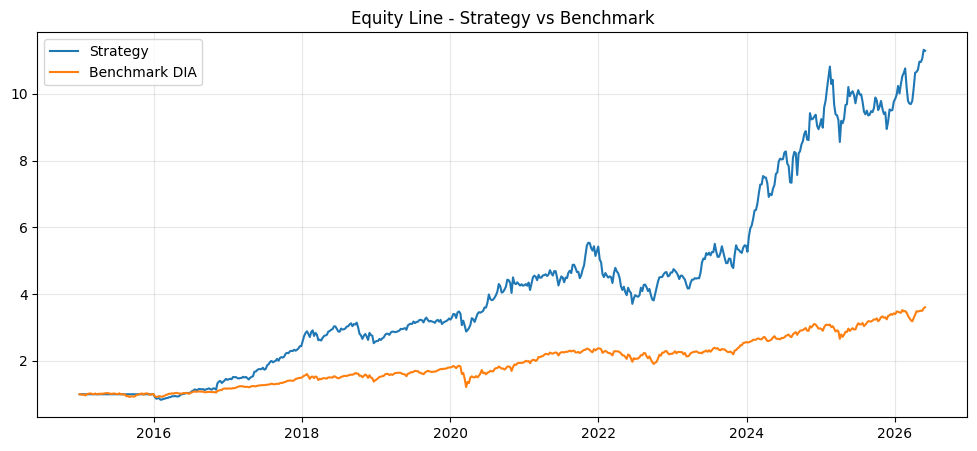

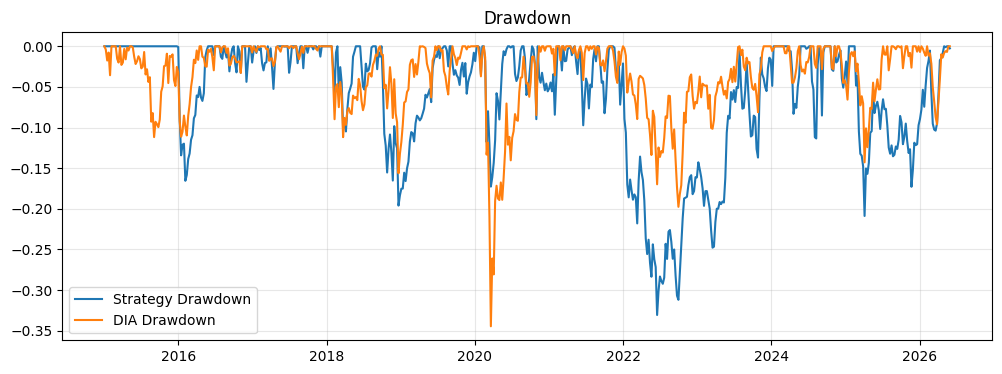

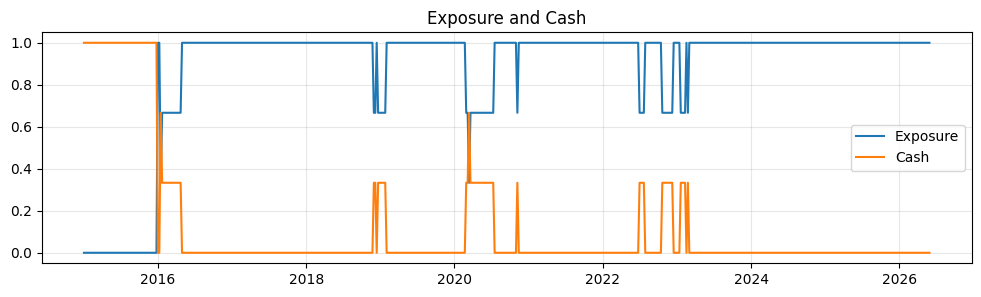

Best metrics:


,Value
CAGR,0.235475
Volatility,0.208612
Sharpe_1pct,1.071424
Information_Ratio,0.629448
MaxDD,-0.330825
Final_Equity,11.286504
Benchmark_Final_Equity,3.606236
Avg_Turnover,0.200783
Avg_Exposure,0.877517


In [35]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere file Excel con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 9 - GRAFICI EQUITY, DRAWDOWN, EXPOSURE
# =============================

best_result = best_run['result']

plt.figure(figsize=(12, 5))
plt.plot(best_result.index, best_result['Strategy_Equity'], label='Strategy')
plt.plot(best_result.index, best_result['Benchmark_Equity'], label=f'Benchmark {benchmark}')
plt.title('Equity Line - Strategy vs Benchmark')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(best_result.index, best_result['Strategy_Drawdown'], label='Strategy Drawdown')
plt.plot(best_result.index, best_result['Benchmark_Drawdown'], label=f'{benchmark} Drawdown')
plt.title('Drawdown')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(best_result.index, best_result['Exposure'], label='Exposure')
plt.plot(best_result.index, best_result['CASH'], label='Cash')
plt.title('Exposure and Cash')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('Best metrics:')
display(pd.DataFrame([best_run['metrics']]).T.rename(columns={0: 'Value'}))

In [36]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere file Excel con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 10 - ALLOCATION REPORT ULTIME SETTIMANE
# =============================

LAST_N_WEEKS = 8
weights_best = best_run['weights']
last_alloc = weights_best.tail(LAST_N_WEEKS).T
last_alloc.columns = [d.strftime('%Y-%m-%d') for d in last_alloc.columns]
last_alloc_pct = (last_alloc * 100).round(1)

print('Allocation report - ultime settimane')
display(last_alloc_pct)

last_date = weights_best.index[-1]
last_selected = best_run['selected_by_date'][last_date]
print('Ultima data:', last_date.date())
print('Ticker selezionati:', last_selected)
print('Cash %:', round(weights_best.loc[last_date, 'CASH'] * 100, 1))


Allocation report - ultime settimane


,2026-04-10,2026-04-17,2026-04-24,2026-05-01,2026-05-08,2026-05-15,2026-05-22,2026-05-29
AAPL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AMGN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AMZN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AXP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CAT,33.3,33.3,33.3,33.3,33.3,33.3,33.3,33.3
CRM,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CSCO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.3
CVX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DIS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Ultima data: 2026-05-29
Ticker selezionati: ['CAT', 'MRK', 'CSCO']
Cash %: 0.0


Market Regime Table: 2026-05-29


,Ticker,Slope,R2,Score,Pass_Trend,Pass_Stability,Selected,Note
0,CAT,0.018148,0.969271,0.017590,True,True,True,Selected
1,MRK,0.010604,0.881663,0.009349,True,True,True,Selected
2,JNJ,0.009862,0.901313,0.008889,True,True,False,Rejected - Correlation / Ranking
3,CSCO,0.008414,0.717048,0.006033,True,True,True,Selected
4,WMT,0.006939,0.869156,0.006031,True,True,False,Rejected - Correlation / Ranking
5,GS,0.007509,0.786770,0.005908,True,True,False,Rejected - Correlation / Ranking
6,CVX,0.006764,0.762375,0.005157,True,True,False,Rejected - Correlation / Ranking
7,AAPL,0.006280,0.678792,0.004263,True,True,False,Rejected - Correlation / Ranking
8,AMGN,0.005528,0.684727,0.003785,True,True,False,Rejected - Correlation / Ranking
9,TRV,0.003322,0.774935,0.002574,True,True,False,Rejected - Correlation / Ranking


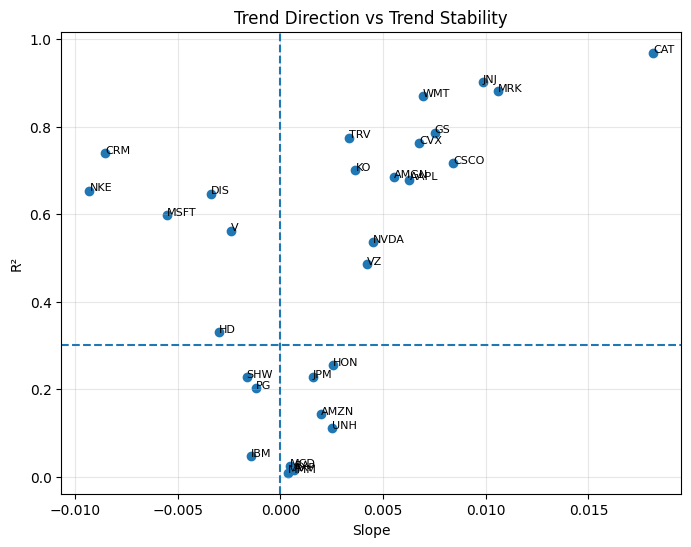

In [37]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere file Excel con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 11 - MARKET REGIME TABLE ULTIMA DATA
# =============================

last_date = px_univ.index[-1]
last_ranking = best_run['ranking_by_date'][last_date].copy()

if last_ranking.empty:
    print('Ranking vuoto per ultima data.')
else:
    def regime_note(row):
        # Crea una nota sintetica sul motivo della selezione/scarto.
        if row.get('Selected', False):
            return 'Selected'
        if not row.get('Pass_Trend', False):
            return 'Rejected - No Trend'
        if not row.get('Pass_Stability', False):
            return 'Rejected - No Stability'
        return 'Rejected - Correlation / Ranking'

    last_ranking['Note'] = last_ranking.apply(regime_note, axis=1)
    display_cols = ['Ticker', 'Slope', 'R2', 'Score', 'Pass_Trend', 'Pass_Stability', 'Selected', 'Note']

    print('Market Regime Table:', last_date.date())
    display(last_ranking[display_cols].reset_index(drop=True))

    plt.figure(figsize=(8, 6))
    plt.scatter(last_ranking['Slope'], last_ranking['R2'])
    for _, row in last_ranking.iterrows():
        plt.annotate(row['Ticker'], (row['Slope'], row['R2']), fontsize=8)
    plt.axvline(best_run['params']['slope_min'], linestyle='--')
    plt.axhline(best_run['params']['r2_min'], linestyle='--')
    plt.title('Trend Direction vs Trend Stability')
    plt.xlabel('Slope')
    plt.ylabel('R²')
    plt.grid(True, alpha=0.3)
    plt.show()


In [38]:
# 2026-05-29 08:30 Europe/Rome — PROMPT: "riscrivi notebook: leggere file Excel con ticker, primo ticker benchmark, download da yfinance"
# =============================
# CELL 12 - EXPORT EXCEL
# =============================

timestamp = datetime.now(ZoneInfo('Europe/Rome')).strftime('%Y%m%d_%H%M')
excel_out = OUTPUT_DIR / f'TA_Portfolios_yfinance_{timestamp}.xlsx'

with pd.ExcelWriter(excel_out, engine='xlsxwriter') as writer:
    pd.DataFrame({
        'Benchmark': [benchmark],
        'Universe_Tickers': [', '.join(px_univ.columns)],
        'Start_Date': [str(px_univ.index.min().date())],
        'End_Date': [str(px_univ.index.max().date())],
        'K_Select': [K_SELECT],
        'Transaction_Cost': [TRANSACTION_COST]
    }).to_excel(writer, sheet_name='Setup', index=False)

    runs_df.to_excel(writer, sheet_name='Grid_Search', index=False)
    pd.DataFrame([best_run['params']]).to_excel(writer, sheet_name='Best_Params', index=False)
    pd.DataFrame([best_run['metrics']]).to_excel(writer, sheet_name='Best_Metrics', index=False)
    best_result.to_excel(writer, sheet_name='Best_Backtest')
    best_run['weights'].to_excel(writer, sheet_name='Best_Weights')
    last_alloc_pct.to_excel(writer, sheet_name='Last_Allocation')

    if 'last_ranking' in globals() and not last_ranking.empty:
        last_ranking.to_excel(writer, sheet_name='Last_Regime', index=False)

print('Excel esportato:')
print(excel_out)


Excel esportato:
/content/drive/MyDrive/AssetAllocation/Output/TA_Portfolios_yfinance_20260531_0819.xlsx


In [39]:
print(GOOGLE_SHEET_CSV_URL)

https://docs.google.com/spreadsheets/d/11qNgaa-9S2SABWe2emZHUDZ-xLkeef0KA00n5FXxPIQ/export?format=csv&gid=0
